**Data** **Description**

The file train.csv contains metrics and other details of about 15000 youtube videos. The metrics include number of views,likes,dislikes,comments and apart from that published date,duration and category are also included. The train.csv file also contains the metric number of adviews which is our target variable for prediction


Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

Importing data

In [2]:
path = "" # put path of your folder of your data if it's not in the same folder
data_train = pd.read_csv(path + "train.csv")

In [3]:
data_train.head()

,vidid,adview,views,likes,dislikes,comment,published,duration,category
0,VID_18655,40,1031602,8523,363,1095,2016-09-14,PT7M37S,F
1,VID_14135,2,1707,56,2,6,2016-10-01,PT9M30S,D
2,VID_2187,1,2023,25,0,2,2016-07-02,PT2M16S,C
3,VID_23096,6,620860,777,161,153,2016-07-27,PT4M22S,H
4,VID_10175,1,666,1,0,0,2016-06-29,PT31S,D


In [4]:
data_train.shape

(14999, 9)

Assigning each category a number for Category feature

In [5]:
category = {'A': 1, 'B': 2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7, 'H':8}
data_train["category"] = data_train["category"].map(category)
data_train.head()

,vidid,adview,views,likes,dislikes,comment,published,duration,category
0,VID_18655,40,1031602,8523,363,1095,2016-09-14,PT7M37S,6
1,VID_14135,2,1707,56,2,6,2016-10-01,PT9M30S,4
2,VID_2187,1,2023,25,0,2,2016-07-02,PT2M16S,3
3,VID_23096,6,620860,777,161,153,2016-07-27,PT4M22S,8
4,VID_10175,1,666,1,0,0,2016-06-29,PT31S,4


Removing character "F" present in data

In [6]:
data_train = data_train[data_train.views!='F']
data_train = data_train[data_train.likes!='F']
data_train = data_train[data_train.dislikes!='F']
data_train = data_train[data_train.comment!='F']

Convert values to integers for views, likes, dislikes, comments and adview

In [7]:
data_train["views"] = pd.to_numeric(data_train["views"])
data_train["comment"] = pd.to_numeric(data_train["comment"])
data_train["likes"] = pd.to_numeric(data_train["likes"])
data_train["dislikes"] = pd.to_numeric(data_train["dislikes"])
data_train["adview"] = pd.to_numeric(data_train["adview"])

In [8]:
column_vidid = data_train['vidid']

Encoding features like category, Duration, Vidid

In [9]:
from sklearn.preprocessing import LabelEncoder
data_train['duration'] = LabelEncoder().fit_transform(data_train['duration'])
data_train['vidid'] = LabelEncoder().fit_transform(data_train['vidid'])
data_train['published'] = LabelEncoder().fit_transform(data_train['published'])

In [10]:
data_train.head()

,vidid,adview,views,likes,dislikes,comment,published,duration,category
0,5912,40,1031602,8523,363,1095,2168,2925,6
1,2741,2,1707,56,2,6,2185,3040,4
2,8138,1,2023,25,0,2,2094,1863,3
3,9005,6,620860,777,161,153,2119,2546,8
4,122,1,666,1,0,0,2091,1963,4


Convert Time_in_sec for duration

In [11]:
import datetime
import time

In [12]:
def checki(x):
    y = x[2:]
    h = ''
    m = '' 
    s = ''
    nm = ''
    p = ['H', 'M', 'S']
    for i in y:
        if i not in p:
            nm+=i
        else:
            if(i=="H"):
                h = nm
                nm = ''
            elif(i=="H"):
                m = nm
                nm = ''
            else:
                s = nm
                nm = ''
    if(h==''):
        h = '00'
    if(m == ''):
        m = '00'
    if(s==''):
        s = '00'
    bp = h+':'+m+':'+s
    return bp

In [13]:
train = pd.read_csv("train.csv")
mp = pd.read_csv(path + "train.csv")["duration"]
time = mp.apply(checki)

In [14]:
def func_sec(time_string):
    h, m, s = time_string.split(':')
    return int(h) * 3600 + int(m) * 60 + int(s)

In [15]:
time1 = time.apply(func_sec)

In [16]:
data_train["duration"] = time1
data_train.head()

,vidid,adview,views,likes,dislikes,comment,published,duration,category
0,5912,40,1031602,8523,363,1095,2168,37,6
1,2741,2,1707,56,2,6,2185,30,4
2,8138,1,2023,25,0,2,2094,16,3
3,9005,6,620860,777,161,153,2119,22,8
4,122,1,666,1,0,0,2091,31,4


# VISUALISATION
Individual plots
     

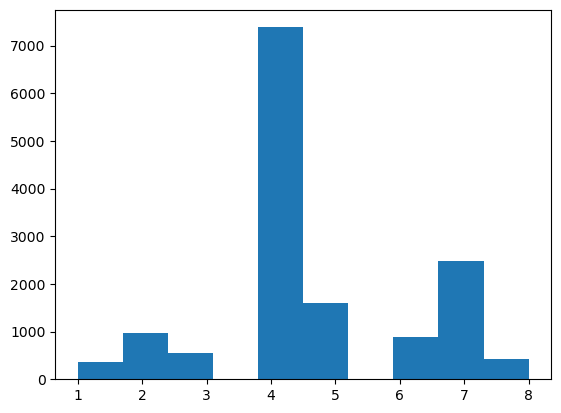

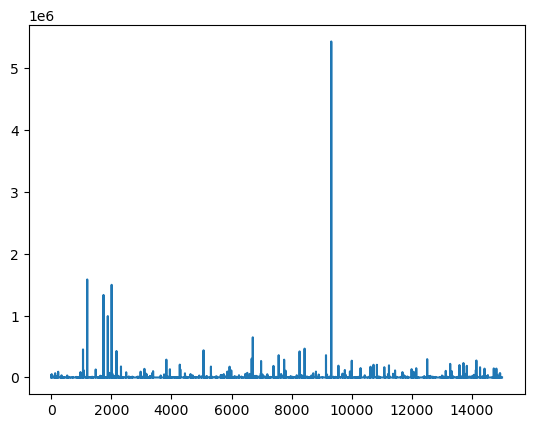

In [17]:
plt.hist(data_train["category"])
plt.show()
plt.plot(data_train["adview"])
plt.show()

Remove videos with adview greater than 2000000 as outlier

In [18]:
data_train = data_train[data_train["adview"]<2000000]

In [19]:
# Heatmap
import seaborn as sns

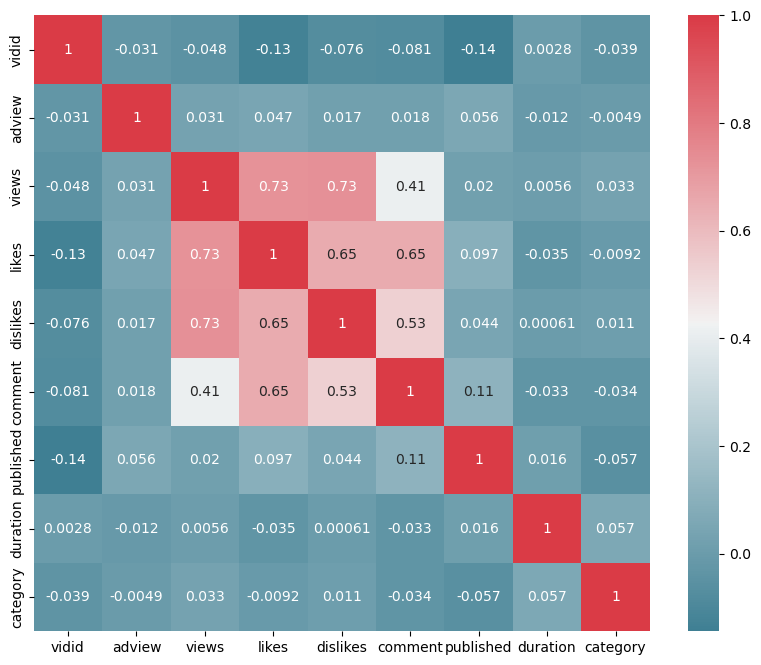

In [20]:
f, ax = plt.subplots(figsize=(10,8))
corr = data_train.corr()
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=np.bool), cmap=sns.diverging_palette(220, 10, as_cmap=True), square=True, ax=ax, annot=True)
plt.show()

split data

In [21]:
Y_train = pd.DataFrame(data_train.iloc[:, 1].values, columns = ['target'])
data_train = data_train.drop(["adview"],axis=1)
data_train = data_train.drop(["vidid"],axis=1)
data_train.head()

,views,likes,dislikes,comment,published,duration,category
0,1031602,8523,363,1095,2168,37,6
1,1707,56,2,6,2185,30,4
2,2023,25,0,2,2094,16,3
3,620860,777,161,153,2119,22,8
4,666,1,0,0,2091,31,4


In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data_train, Y_train, test_size=0.2, random_state = 42)

In [23]:
X_train.shape

(11708, 7)

Normalise Data

In [24]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

Evaluation Metrics

In [25]:
from sklearn import metrics
def print_error(X_test, y_test, model_name):
    prediction = model_name.predict(X_test)
    print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, prediction))
    print('Mean Squared Error:', metrics.mean_squared_error(y_test, prediction))
    print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, prediction)))

Linear Regression

In [26]:
from sklearn import linear_model
linear_regression = linear_model.LinearRegression()
linear_regression.fit(X_train, y_train)
print_error(X_test, y_test, linear_regression)

Mean Absolute Error: 3706.784776672818
Mean Squared Error: 835976751.020201
Root Mean Squared Error: 28913.262545416783


Desicion Tree Regressor

In [27]:
from sklearn.tree import DecisionTreeRegressor
decision_tree = DecisionTreeRegressor()
decision_tree.fit(X_train, y_train)
print_error(X_test, y_test, decision_tree)

Mean Absolute Error: 2400.7418032786886
Mean Squared Error: 640601300.1086066
Root Mean Squared Error: 25310.10272813223


Random Forest Regressor

In [28]:
from sklearn.ensemble import RandomForestRegressor
n_estimators = 200
max_depth = 25
min_samples_split = 15
min_samples_leaf = 2
random_forest = RandomForestRegressor(n_estimators = n_estimators,  max_depth = max_depth, min_samples_split = min_samples_split, min_samples_leaf= min_samples_leaf)
random_forest.fit(X_train, y_train)
print_error(X_test, y_test, random_forest)

Mean Absolute Error: 3537.9077804972317
Mean Squared Error: 645707336.7626345
Root Mean Squared Error: 25410.772061522148


Support Vector Regressor

In [29]:
from sklearn.svm import SVR
supportvector_regressor = SVR()
supportvector_regressor.fit(X_train,y_train)
print_error(X_test, y_test, supportvector_regressor)

Mean Absolute Error: 1696.9477891687952
Mean Squared Error: 833685937.7424116
Root Mean Squared Error: 28873.62010109594


Artificial Neural Network

In [30]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
import keras
from keras.layers import Dense

X = data_train_numeric.drop(columns=['adview'])  # Features
y = data_train_numeric['adview']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Impute missing values in testing data
imputer = SimpleImputer(strategy='mean')
X_test_imputed = imputer.fit_transform(X_test)

ImportError: To use Keras, you need to have `optree` installed. Install it via `pip install optree`

In [ ]:
ann = keras.models.Sequential([Dense(6, activation="relu",
                               input_shape=X_train.shape[1:]),
                               Dense(6,activation="relu"),
                               Dense(1)])

In [ ]:
import keras.optimizers
opt = "adam"
loss = keras.losses.mean_squared_error
ann.compile(optimizer=opt, loss=loss, metrics=["mean_absolute_error"])

In [ ]:
history = ann.fit(X_train,y_train,epochs=100)

In [ ]:
ann.summary()

In [ ]:
print_error(X_test,y_test,ann)

Saving Scikitlearn models

In [ ]:
import joblib
joblib.dump(decision_tree,"decisiontree_youtubeadview.pkl")

Saving Keras Atrificial Neural Network model

In [ ]:
ann.save("ann_youtubeadview.h5")

In [ ]:
prediction = decision_tree.predict(X_test)

In [ ]:
prediction=pd.DataFrame(prediction)
prediction.info()

In [ ]:
prediction = prediction.rename(columns={0: "Adview"})

In [ ]:
prediction.head()

In [ ]:
prediction.to_csv('predictions.csv')